In [2]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Import el separador de muestras para entrenamiento y pruebas
from sklearn.model_selection import train_test_split

In [5]:
# Cargar conjunto de datos
datos = sns.load_dataset('iris')
print(datos)
print(datos.describe())

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.05

In [6]:
print(datos['species'].size) 
print(datos.groupby('species').size())  

150
species
setosa        50
versicolor    50
virginica     50
dtype: int64


In [7]:
# Seleccionar datos de prueba y entrenamiento
train, test = train_test_split(datos, test_size=0.4, stratify=datos['species'], random_state=26)
print(train)

     sepal_length  sepal_width  petal_length  petal_width     species
97            6.2          2.9           4.3          1.3  versicolor
69            5.6          2.5           3.9          1.1  versicolor
41            4.5          2.3           1.3          0.3      setosa
33            5.5          4.2           1.4          0.2      setosa
31            5.4          3.4           1.5          0.4      setosa
..            ...          ...           ...          ...         ...
46            5.1          3.8           1.6          0.2      setosa
134           6.1          2.6           5.6          1.4   virginica
102           7.1          3.0           5.9          2.1   virginica
65            6.7          3.1           4.4          1.4  versicolor
91            6.1          3.0           4.6          1.4  versicolor

[90 rows x 5 columns]


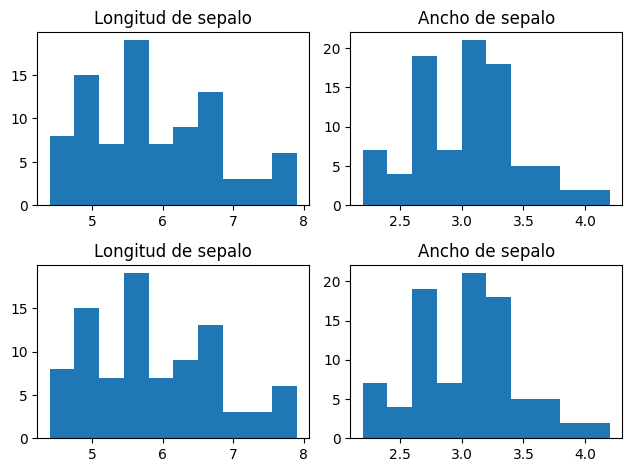

In [8]:
# Exploracion visual
# Generacion de histogramas
n_bins = 10
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
ax1.hist(train['sepal_length'], bins=n_bins)
ax1.set_title('Longitud de sepalo')
ax2.hist(train['sepal_width'], bins=n_bins)
ax2.set_title('Ancho de sepalo')
ax3.hist(train['sepal_length'], bins=n_bins)
ax3.set_title('Longitud de sepalo')
ax4.hist(train['sepal_width'], bins=n_bins)
ax4.set_title('Ancho de sepalo')
fig.tight_layout(pad=1.0)
plt.show()

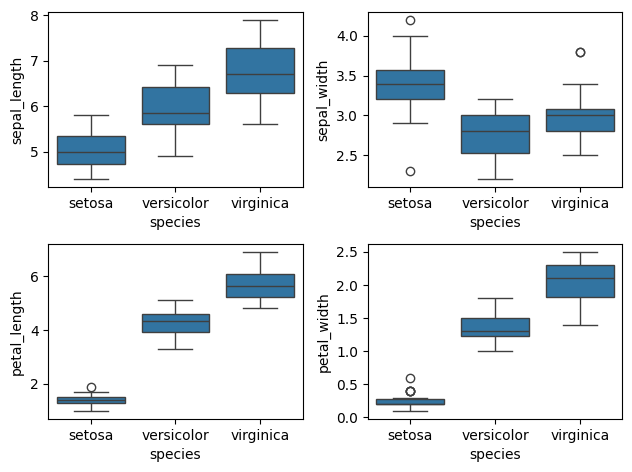

In [10]:
# Diagrama Box-plot
fig1, axs1 = plt.subplots(nrows=2, ncols=2)
fn = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
cn = ['setosa', 'versicolor', 'virginica']
sns.boxplot(x='species', y=fn[0], data=train, order=cn, ax=axs1[0, 0])
sns.boxplot(x='species', y=fn[1], data=train, order=cn, ax=axs1[0, 1])
sns.boxplot(x='species', y=fn[2], data=train, order=cn, ax=axs1[1, 0])
sns.boxplot(x='species', y=fn[3], data=train, order=cn, ax=axs1[1, 1])
fig1.tight_layout(pad=1.0)
plt.show()

<Axes: xlabel='species', ylabel='sepal_length'>

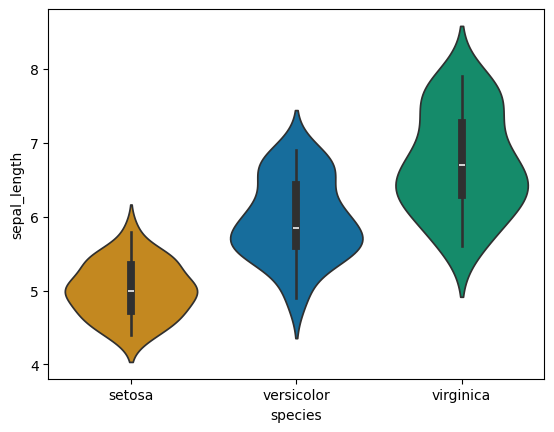

In [12]:
# Grafico de violin
sns.violinplot(x='species', y='sepal_length', data = train, hue = 'species', order=cn, palette='colorblind')

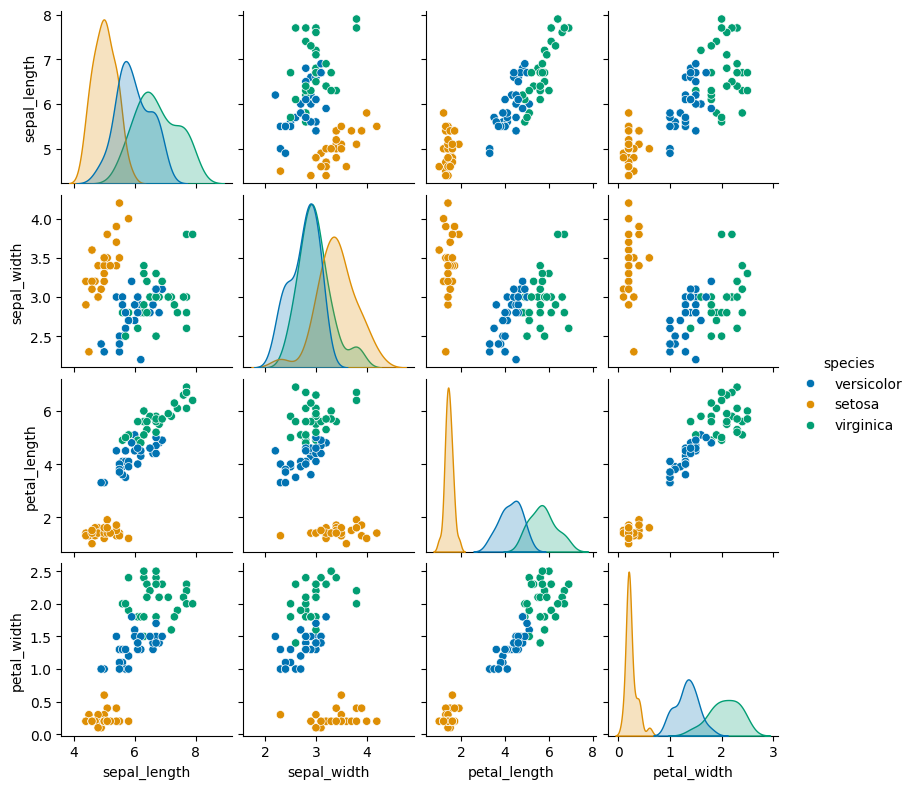

In [15]:
# Diagrama de dispersion de atributos emparejados
sns.pairplot(data=train, hue='species', height=2, palette='colorblind')

In [17]:
corrmat = train.corr(numeric_only = True)
corrmat

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.114096,0.879588,0.811911
sepal_width,-0.114096,1.000000,-0.414369,-0.360677
petal_length,0.879588,-0.414369,1.000000,0.959529
petal_width,0.811911,-0.360677,0.959529,1.000000


<Axes: >

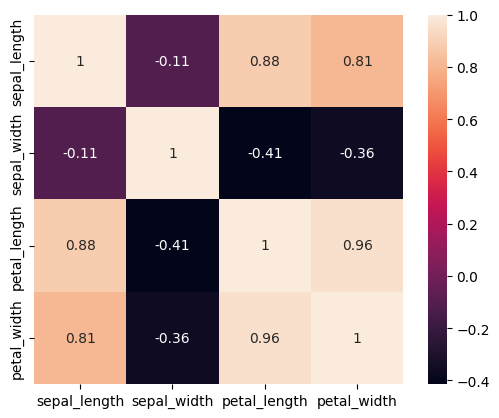

In [20]:
sns.color_palette('mako', as_cmap = True)
sns.heatmap(corrmat, annot=True, square=True)

<Axes: >

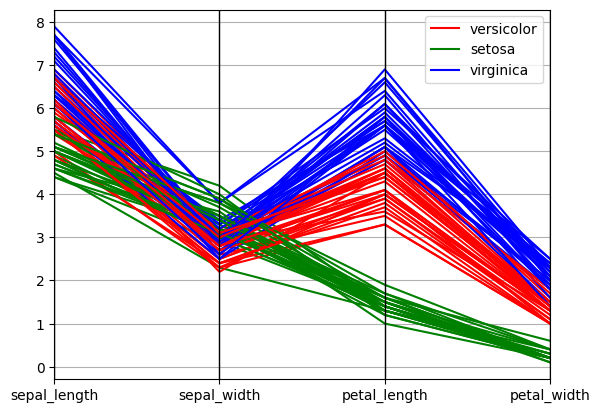

In [21]:
from pandas.plotting import parallel_coordinates
parallel_coordinates(train, 'species', color=['red', 'green', 'blue'])